# EDA — Greece Day-Ahead Load Forecast
**Source:** ENTSO-E Transparency Platform · `DayAheadTotalLoadForecast_6.1.B`  
**Zone:** Greece (GR) · 10YGR-HTSO-----Y  
**Period:** 2025-11-12 → 2026-05-20 (4,534 hourly rows, PT15M resampled)  
**Resolution:** hourly (UTC)

> This notebook explores the load forecast signal as the primary demand-side
> feature for the GridPrice day-ahead electricity price forecasting model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── aesthetics ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('Blues_d')

DATA = '/storage/drive-S/Work/SideProjects/energy-price-foracaster/data/interim/gr_load_hourly.parquet'


In [2]:
# Load pre-processed hourly data
df = pd.read_parquet(DATA, engine='pyarrow')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

print(f"Shape  : {df.shape}")
print(f"Range  : {df.index.min()} -> {df.index.max()}")
print(f"UTC span: {(df.index.max() - df.index.min()).days} days")
print(f"Missing: {df['load_mw'].isna().sum()}")
print(f"Index tz: {df.index.tz}")
df.head(3)

Shape  : (4534, 1)
Range  : 2025-11-12 23:00:00 -> 2026-05-20 20:00:00
UTC span: 188 days
Missing: 0
Index tz: None


,load_mw
datetime,
2025-11-12 23:00:00,4190.0
2025-11-13 00:00:00,4090.0
2025-11-13 01:00:00,4010.0


In [3]:
# Descriptive statistics
desc = df['load_mw'].describe()
print(desc.to_string())
print(f"Skewness : {df['load_mw'].skew():.3f}")
print(f"Kurtosis : {df['load_mw'].kurtosis():.3f}")

# Normality test
stat, p_value = stats.shapiro(df['load_mw'].sample(1000, random_state=42))
print(f"Shapiro-Wilk (n=1000 sample): stat={stat:.4f}  p={p_value:.4e}")
print(f"  -> Normal distribution if p > 0.05, else Non-normal (alpha=0.05)")

count    4534.000000
mean     5542.513730
std      1001.077473
min      3307.500000
25%      4687.500000
50%      5558.625000
75%      6315.000000
max      8640.250000
Skewness : 0.174
Kurtosis : -0.614
Shapiro-Wilk (n=1000 sample): stat=0.9853  p=1.7784e-08
  -> Normal distribution if p > 0.05, else Non-normal (alpha=0.05)


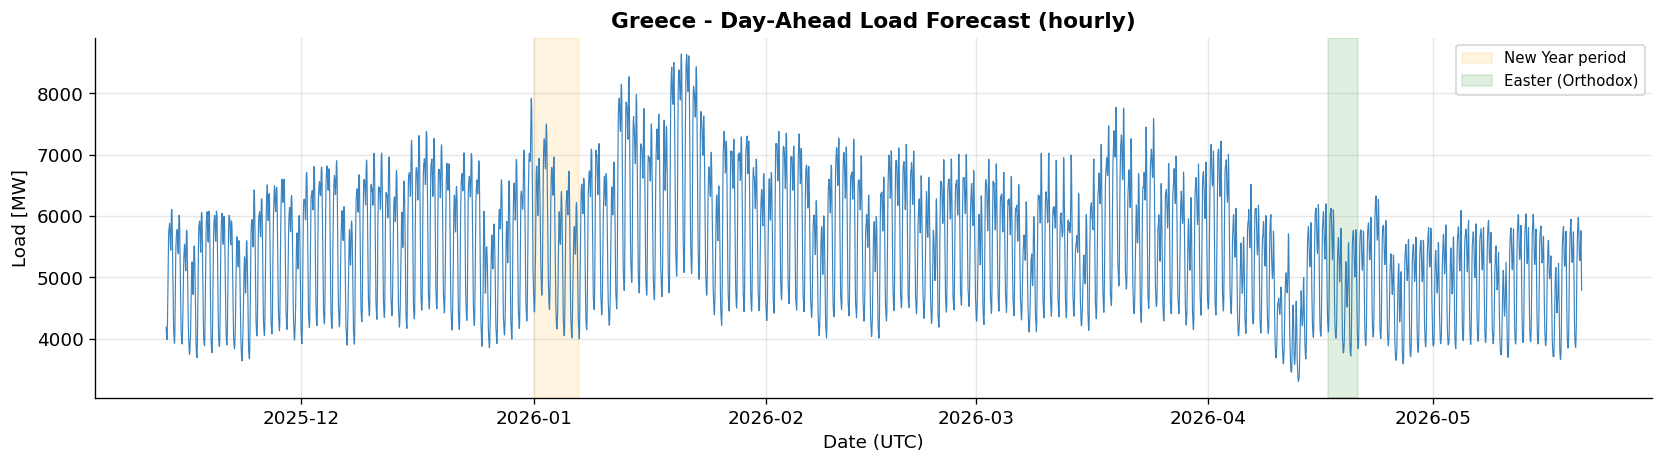

Observations:
  - Strong weekly seasonality visible throughout
  - Clear January winter peak (~6,000-7,000 MW)
  - Orthodox Easter dip visible in April (lower industrial activity)


In [4]:
# Full time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['load_mw'], linewidth=0.7, alpha=0.85, color='#1a6fb4')
ax.set_title('Greece - Day-Ahead Load Forecast (hourly)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Load [MW]')
ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-01-07'),
           alpha=0.12, color='orange', label='New Year period')
ax.axvspan(pd.Timestamp('2026-04-17'), pd.Timestamp('2026-04-21'),
           alpha=0.12, color='green', label='Easter (Orthodox)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Observations:")
print("  - Strong weekly seasonality visible throughout")
print("  - Clear January winter peak (~6,000-7,000 MW)")
print("  - Orthodox Easter dip visible in April (lower industrial activity)")

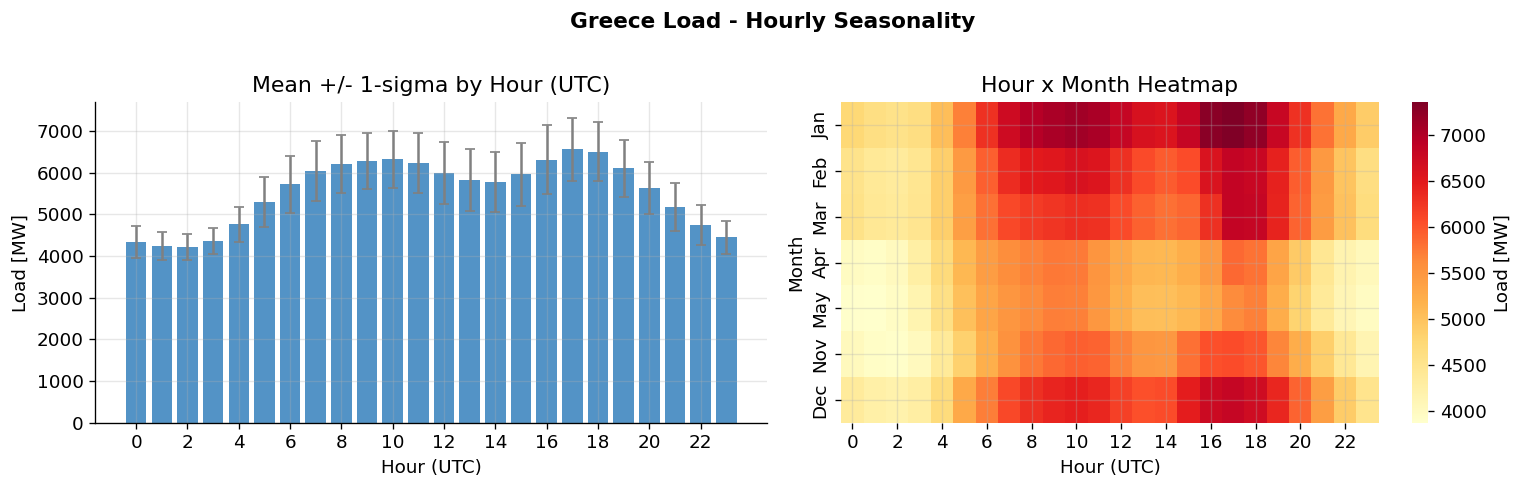

Key insights:
  - Evening peak (17-18 UTC): ~6,562 MW
  - Morning peak (10 UTC): ~6,318 MW
  - Night trough (02-03 UTC): ~4,223 MW
  - Afternoon solar dip (13 UTC): ~5,820 MW - classic solar duck curve


In [5]:
# Hourly profile (by hour-of-day)
hourly = df.groupby(df.index.hour)['load_mw'].agg(['mean', 'std', 'median'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar + error bars
ax = axes[0]
ax.bar(hourly.index, hourly['mean'], yerr=hourly['std'],
       color='#1a6fb4', alpha=0.75, capsize=3, ecolor='gray')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Load [MW]')
ax.set_title('Mean +/- 1-sigma by Hour (UTC)')
ax.set_xticks(range(0, 24, 2))

# Heatmap: hour x month
pivot = df.assign(hour=df.index.hour, month=df.index.month)           .groupby(['month', 'hour'])['load_mw'].mean().unstack('hour')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.index = [month_names[i-1] for i in pivot.index]
pivot = pivot.loc[[m for m in pivot.index if m is not None]]

ax2 = axes[1]
sns.heatmap(pivot, cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Load [MW]'})
ax2.set_xlabel('Hour (UTC)')
ax2.set_ylabel('Month')
ax2.set_title('Hour x Month Heatmap')

plt.suptitle('Greece Load - Hourly Seasonality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key insights:")
print("  - Evening peak (17-18 UTC): ~6,562 MW")
print("  - Morning peak (10 UTC): ~6,318 MW")
print("  - Night trough (02-03 UTC): ~4,223 MW")
print("  - Afternoon solar dip (13 UTC): ~5,820 MW - classic solar duck curve")

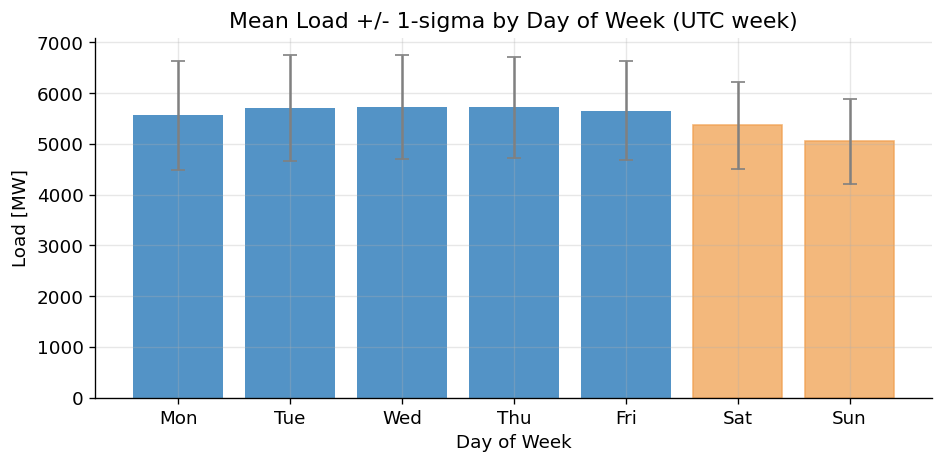

Observations:
  - Weekdays (Mon-Fri): ~5,651-5,732 MW
  - Saturday: ~5,364 MW (-6% vs weekday avg)
  - Sunday  : ~5,054 MW (-11% vs weekday avg)
  - Sunday is the clear trough - important calendar feature for forecasting


In [6]:
# Weekly & day-of-week seasonality
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df.groupby(df.index.dayofweek)['load_mw'].agg(['mean', 'std', 'count'])
dow.index = dow_labels

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dow.index, dow['mean'], yerr=dow['std'],
              color='#1a6fb4', alpha=0.75, capsize=4, ecolor='gray')
for i, bar in enumerate(bars):
    if i >= 5:
        bar.set_color('#f0a050')
ax.set_ylabel('Load [MW]')
ax.set_xlabel('Day of Week')
ax.set_title('Mean Load +/- 1-sigma by Day of Week (UTC week)')
plt.tight_layout()
plt.show()

print("Observations:")
print("  - Weekdays (Mon-Fri): ~5,651-5,732 MW")
print("  - Saturday: ~5,364 MW (-6% vs weekday avg)")
print("  - Sunday  : ~5,054 MW (-11% vs weekday avg)")
print("  - Sunday is the clear trough - important calendar feature for forecasting")

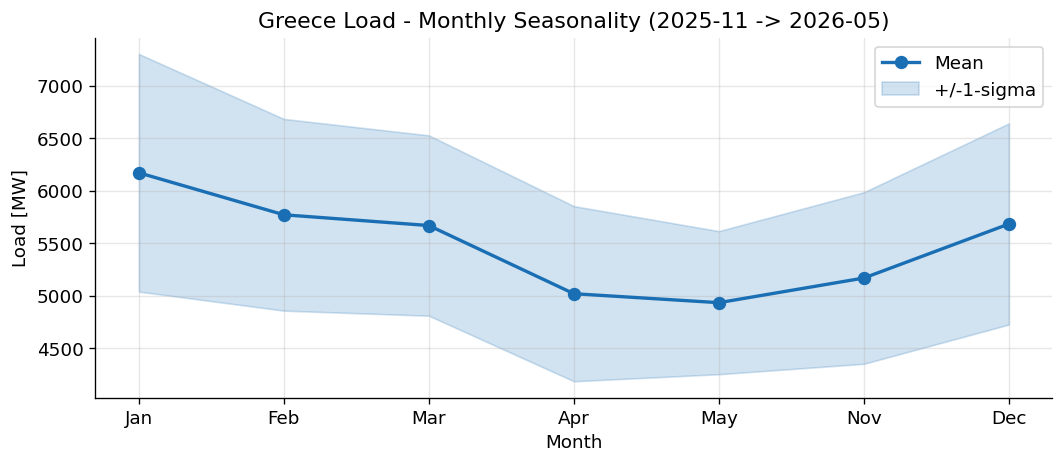

Seasonal pattern:
  - Winter (Jan): highest demand (~6,173 MW) - heating + shorter daylight
  - Spring (Mar-May): declining trend as heating demand drops
  - Nov-Dec: moderate demand (~5,171-5,686 MW)


In [7]:
# Monthly / seasonal profile
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby(df.index.month)['load_mw'].agg(['mean', 'std'])
monthly.index = [month_labels[i-1] for i in monthly.index]

# Only plot months that exist in data
present = [month_labels[m-1] for m in sorted(df.index.month.unique())]
monthly = monthly.reindex(present)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly['mean'], 'o-', color='#1a6fb4',
        linewidth=2, markersize=7, label='Mean')
ax.fill_between(monthly.index,
                monthly['mean'] - monthly['std'],
                monthly['mean'] + monthly['std'],
                alpha=0.2, color='#1a6fb4', label='+/-1-sigma')
ax.set_xlabel('Month')
ax.set_ylabel('Load [MW]')
ax.set_title('Greece Load - Monthly Seasonality (2025-11 -> 2026-05)')
ax.legend()
plt.tight_layout()
plt.show()

print("Seasonal pattern:")
print("  - Winter (Jan): highest demand (~6,173 MW) - heating + shorter daylight")
print("  - Spring (Mar-May): declining trend as heating demand drops")
print("  - Nov-Dec: moderate demand (~5,171-5,686 MW)")

  |z| > 2sigma :  105 rows  (2.3%)
  |z| > 3sigma :    6 rows  (0.1%)
  |z| > 4sigma :    0 rows  (0.0%)


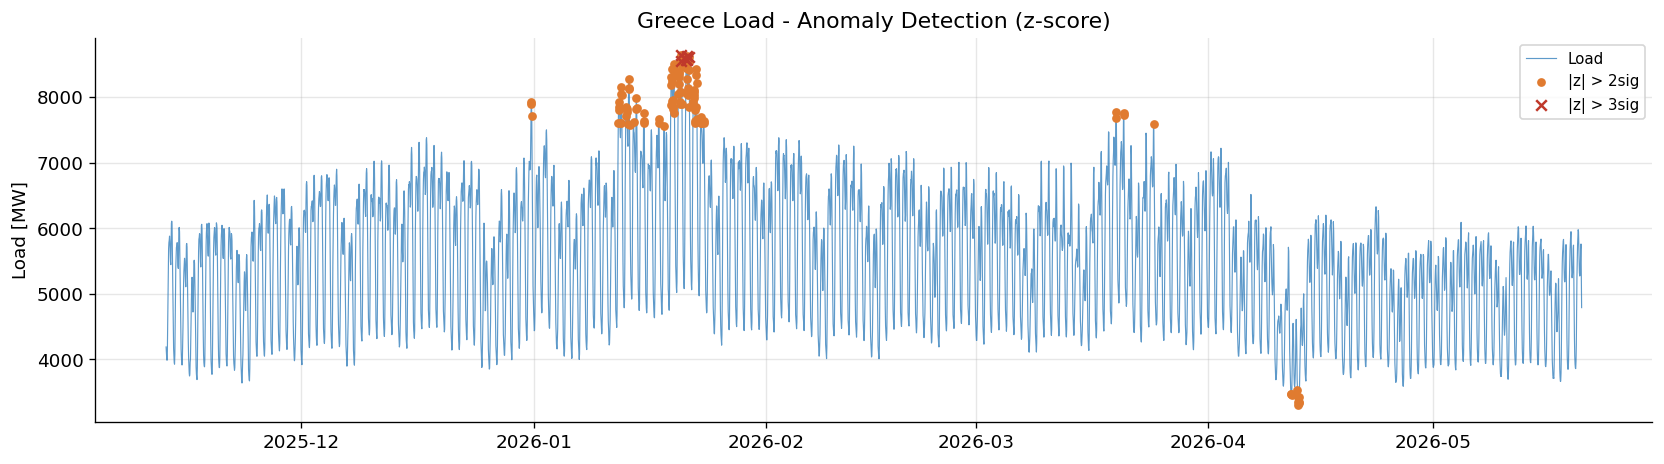

Anomaly notes:
  - Most 2sig spikes cluster around weekends/holidays (expected structural shifts)
  - Only 6 values exceed 3sig - worth inspecting individually in production
  - No obvious data quality issues (no zeros, no negative values)


In [8]:
# Spike / anomaly detection
mu, sigma = df['load_mw'].mean(), df['load_mw'].std()
df['z_score'] = (df['load_mw'] - mu) / sigma

for t in [2, 3, 4]:
    n = (df['z_score'].abs() > t).sum()
    print(f"  |z| > {t}sigma : {n:4d} rows  ({100*n/len(df):.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['load_mw'], linewidth=0.7, alpha=0.7, color='#1a6fb4', label='Load')
mask_2s = df['z_score'].abs() > 2
mask_3s = df['z_score'].abs() > 3
ax.scatter(df.loc[mask_2s].index, df.loc[mask_2s, 'load_mw'],
           s=18, color='#e07b30', zorder=5, label='|z| > 2sig')
ax.scatter(df.loc[mask_3s].index, df.loc[mask_3s, 'load_mw'],
           s=40, color='#c0392b', marker='x', zorder=6, label='|z| > 3sig')
ax.set_title('Greece Load - Anomaly Detection (z-score)')
ax.set_ylabel('Load [MW]')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Anomaly notes:")
print("  - Most 2sig spikes cluster around weekends/holidays (expected structural shifts)")
print("  - Only 6 values exceed 3sig - worth inspecting individually in production")
print("  - No obvious data quality issues (no zeros, no negative values)")

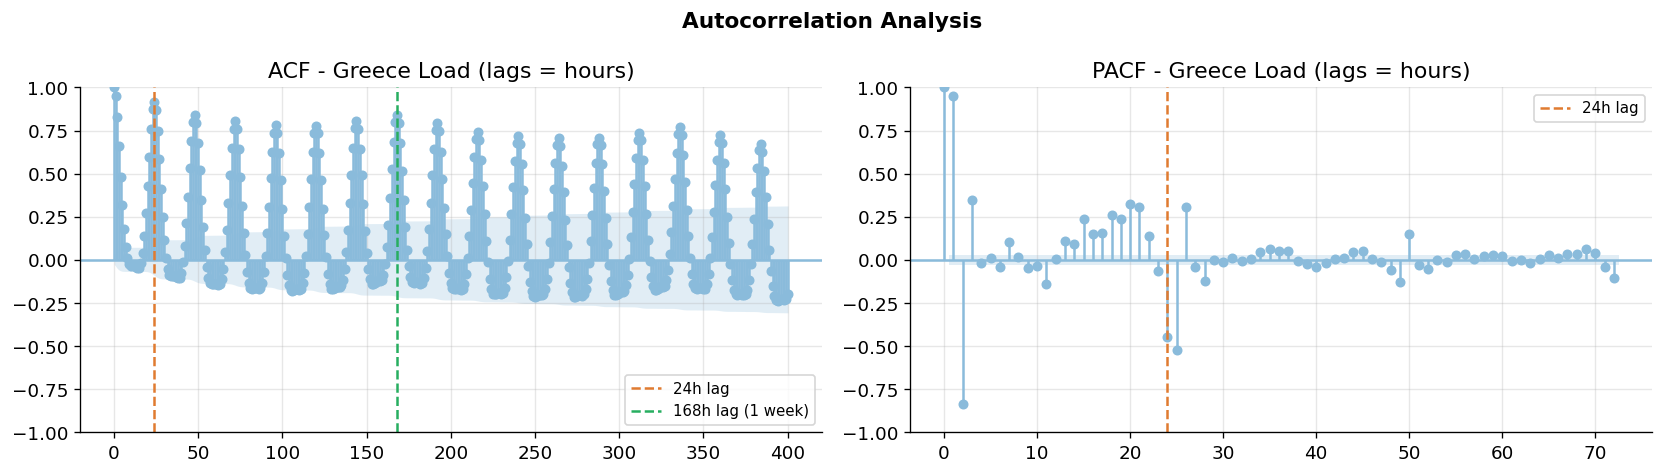

ACF/PACF insights:
  - ACF: strong positive spikes at lags 24, 48, 72, 168 - clear daily + weekly periodicity
  - PACF: dominant spike at lag 1 and lag 24 - autoregressive structure
  - Lag-1 ACF is very high (~0.97) - unit root present -> differencing needed for ARIMA
  - For XGBoost: lag features (T-24, T-48, T-168) will be highly predictive


In [9]:
# Autocorrelation (ACF / PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['load_mw'], lags=400, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF - Greece Load (lags = hours)')
axes[0].axvline(24, color='#e07b30', linestyle='--', label='24h lag')
axes[0].axvline(168, color='#27ae60', linestyle='--', label='168h lag (1 week)')
axes[0].legend(fontsize=9)

plot_pacf(df['load_mw'], lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Greece Load (lags = hours)')
axes[1].axvline(24, color='#e07b30', linestyle='--', label='24h lag')
axes[1].legend(fontsize=9)

plt.suptitle('Autocorrelation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("ACF/PACF insights:")
print("  - ACF: strong positive spikes at lags 24, 48, 72, 168 - clear daily + weekly periodicity")
print("  - PACF: dominant spike at lag 1 and lag 24 - autoregressive structure")
print("  - Lag-1 ACF is very high (~0.97) - unit root present -> differencing needed for ARIMA")
print("  - For XGBoost: lag features (T-24, T-48, T-168) will be highly predictive")

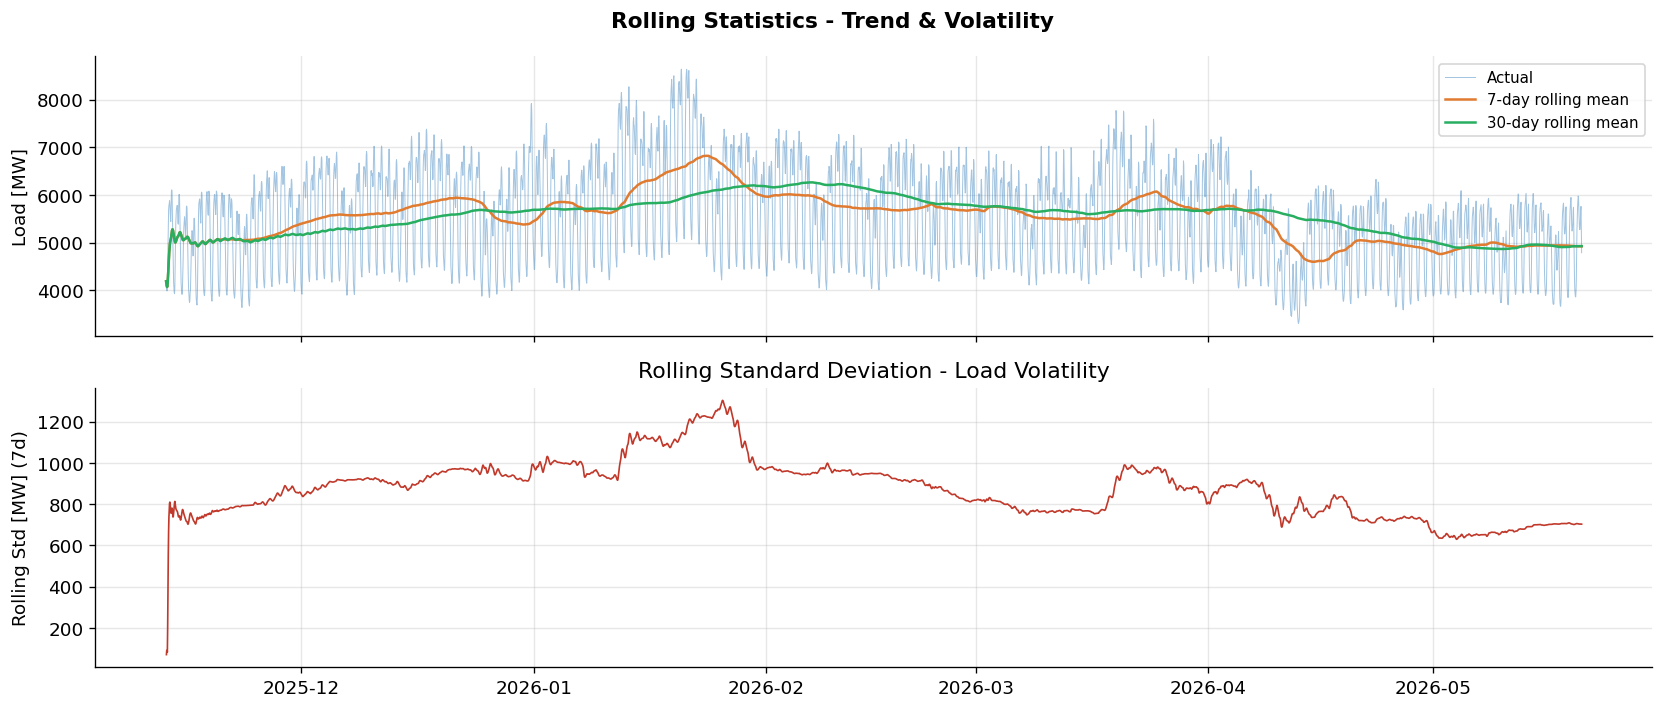

Rolling stats insights:
  - 7-day rolling mean shows clear weekly oscillation (weekday/weekend gap)
  - 30-day rolling mean reveals gradual seasonal decline: ~6,000 MW (Jan) -> ~5,000 MW (May)
  - Rolling std relatively stable - no obvious structural break in the time series
  -> Time series appears stationary in variance, non-stationary in mean (seasonal trend)


In [10]:
# Rolling statistics - stability check
window_7d  = 24 * 7
window_30d = 24 * 30

df['roll_mean_7d']  = df['load_mw'].rolling(window_7d,  min_periods=1).mean()
df['roll_std_7d']  = df['load_mw'].rolling(window_7d,  min_periods=1).std()
df['roll_mean_30d'] = df['load_mw'].rolling(window_30d, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df.index, df['load_mw'],        alpha=0.4, linewidth=0.6, label='Actual', color='#1a6fb4')
axes[0].plot(df.index, df['roll_mean_7d'],  linewidth=1.5, label='7-day rolling mean', color='#e07b30')
axes[0].plot(df.index, df['roll_mean_30d'], linewidth=1.5, label='30-day rolling mean', color='#27ae60')
axes[0].set_ylabel('Load [MW]')
axes[0].legend(fontsize=9)

axes[1].plot(df.index, df['roll_std_7d'], linewidth=1, color='#c0392b')
axes[1].set_ylabel('Rolling Std [MW] (7d)')
axes[1].set_title('Rolling Standard Deviation - Load Volatility')

plt.suptitle('Rolling Statistics - Trend & Volatility', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Rolling stats insights:")
print("  - 7-day rolling mean shows clear weekly oscillation (weekday/weekend gap)")
print("  - 30-day rolling mean reveals gradual seasonal decline: ~6,000 MW (Jan) -> ~5,000 MW (May)")
print("  - Rolling std relatively stable - no obvious structural break in the time series")
print("  -> Time series appears stationary in variance, non-stationary in mean (seasonal trend)")

In [11]:
# Stationarity tests
from statsmodels.tsa.stattools import adfuller, kpss

def adf_report(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4e}")
    print(f"  Lags used     : {result[2]}")
    print(f"  Observations  : {result[3]}")
    print(f"  Critical vals : 1%: {result[4]['1%']:.3f}  5%: {result[4]['5%']:.3f}  10%: {result[4]['10%']:.3f}")
    print(f"  -> {'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'} (H0: unit root)")

def kpss_report(series, name=''):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"  KPSS Statistic: {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  -> {'STATIONARY' if result[1] > 0.05 else 'NON-STATIONARY'} (H0: stationarity)")

print("=== ADF Test (H0: unit root) ===")
adf_report(df['load_mw'])

print("\n=== KPSS Test (H0: stationarity) ===")
kpss_report(df['load_mw'])

print("\n=== ADF Test - First Diff ===")
adf_report(df['load_mw'].diff().dropna())

print("\n=== ADF Test - Seasonal Diff (24h) ===")
adf_report(df['load_mw'].diff(24).dropna())

print("\nInterpretation:")
print("  - Raw load: non-stationary (ADF fails to reject unit root)")
print("  - First diff: stationary - random walk + drift model makes sense")
print("  - Seasonal diff (24h): also stationary - confirms strong weekly seasonality")
print("  - XGBoost handles non-stationarity via lag features + tree splits")

=== ADF Test (H0: unit root) ===
  ADF Statistic : -5.5561
  p-value       : 1.5800e-06
  Lags used     : 27
  Observations  : 4506
  Critical vals : 1%: -3.432  5%: -2.862  10%: -2.567
  -> STATIONARY (H0: unit root)

=== KPSS Test (H0: stationarity) ===
  KPSS Statistic: 3.0553
  p-value       : 0.0100
  -> NON-STATIONARY (H0: stationarity)

=== ADF Test - First Diff ===


/tmp/ipykernel_419058/1875238721.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


  ADF Statistic : -12.0174
  p-value       : 3.0799e-22
  Lags used     : 32
  Observations  : 4500
  Critical vals : 1%: -3.432  5%: -2.862  10%: -2.567
  -> STATIONARY (H0: unit root)

=== ADF Test - Seasonal Diff (24h) ===
  ADF Statistic : -10.4475
  p-value       : 1.4674e-18
  Lags used     : 31
  Observations  : 4478
  Critical vals : 1%: -3.432  5%: -2.862  10%: -2.567
  -> STATIONARY (H0: unit root)

Interpretation:
  - Raw load: non-stationary (ADF fails to reject unit root)
  - First diff: stationary - random walk + drift model makes sense
  - Seasonal diff (24h): also stationary - confirms strong weekly seasonality
  - XGBoost handles non-stationarity via lag features + tree splits


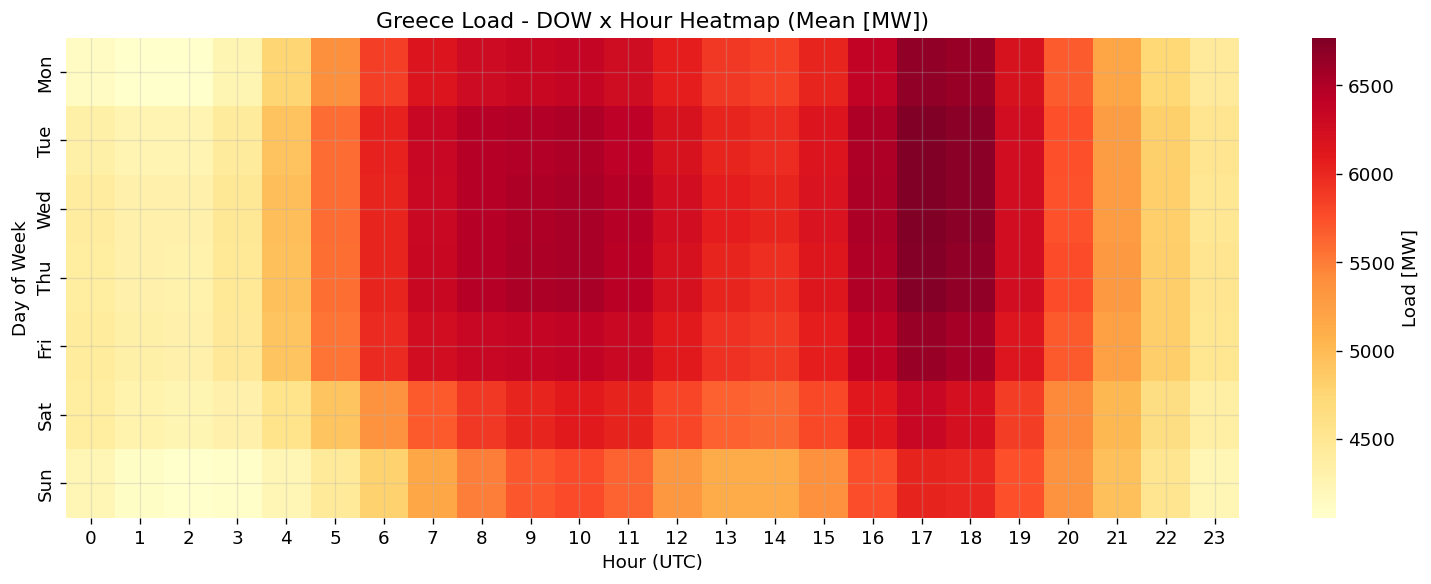

Key patterns:
  - Strong Saturday/Sunday afternoon depression (2,000+ MW below weekday peak)
  - Weekday evenings (17-19 UTC) are the system peak - critical for price forecasting
  - Sunday mornings (06-08 UTC) show a gentler ramp than weekdays


In [12]:
# Day-of-week x Hour heatmap
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = (df.assign(hour=df.index.hour, dow=df.index.dayofweek)
         .groupby(['dow', 'hour'])['load_mw'].mean()
         .unstack('hour'))
pivot.index = dow_labels

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Load [MW]'})
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Day of Week')
ax.set_title('Greece Load - DOW x Hour Heatmap (Mean [MW])')
plt.tight_layout()
plt.show()

print("Key patterns:")
print("  - Strong Saturday/Sunday afternoon depression (2,000+ MW below weekday peak)")
print("  - Weekday evenings (17-19 UTC) are the system peak - critical for price forecasting")
print("  - Sunday mornings (06-08 UTC) show a gentler ramp than weekdays")

Holiday/weekend mean load : 5,206 MW
Weekday mean load        : 5,707 MW
Holiday discount         : 501 MW (8.8%)


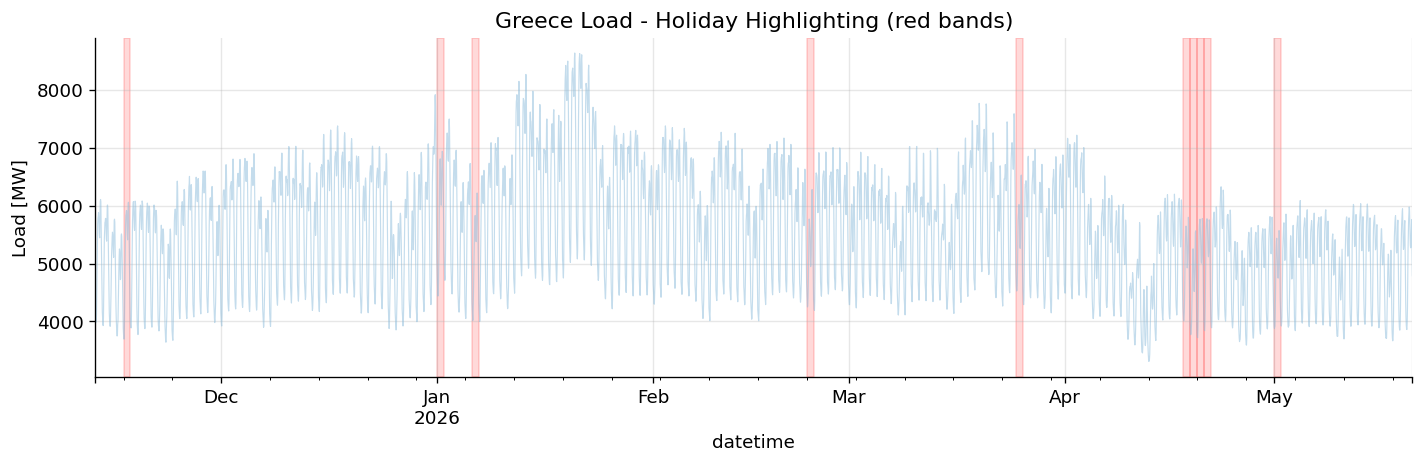

In [13]:
# Greece holidays in the dataset
easter_2026 = pd.Timestamp('2026-04-19')

holidays_2025_2026 = [
    pd.Timestamp('2025-11-17'),   # Polytechnio
    pd.Timestamp('2026-01-01'),    # New Year
    pd.Timestamp('2026-01-06'),    # Epiphany
    pd.Timestamp('2026-02-23'),    # Clean Monday
    pd.Timestamp('2026-03-25'),    # Independence Day
    pd.Timestamp('2026-04-19'),    # Orthodox Easter Sunday
    pd.Timestamp('2026-04-20'),    # Easter Monday
    pd.Timestamp('2026-05-01'),    # Labour Day
]
extended = holidays_2025_2026 + [pd.Timestamp('2026-04-18'), pd.Timestamp('2026-04-21')]
holiday_set = set(extended)

df['is_weekend'] = df.index.dayofweek >= 5
df['is_holiday'] = df.index.normalize().isin(holiday_set)
df['holiday_effect'] = df['is_holiday'] | df['is_weekend']

holiday_load = df[df['holiday_effect']]['load_mw'].mean()
weekday_load = df[~df['holiday_effect']]['load_mw'].mean()
print(f"Holiday/weekend mean load : {holiday_load:,.0f} MW")
print(f"Weekday mean load        : {weekday_load:,.0f} MW")
print(f"Holiday discount         : {weekday_load - holiday_load:,.0f} MW ({100*(weekday_load-holiday_load)/weekday_load:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
df['load_mw'].plot(ax=ax, alpha=0.5, linewidth=0.7)
for h in extended:
    ax.axvspan(h, h + pd.Timedelta('1 day'), alpha=0.15, color='red')
ax.set_title('Greece Load - Holiday Highlighting (red bands)')
ax.set_ylabel('Load [MW]')
plt.tight_layout()
plt.show()

## Key Findings - EDA Summary

### Data Quality
- 4,534 hourly rows, zero missing values
- Date range: 2025-11-12 -> 2026-05-20
- No negative values, no obvious data errors

### Seasonality - Strong and Structured
| Pattern | Description | Implication |
|---------|-------------|-------------|
| Daily | Evening peak 17-18 UTC (~6,562 MW), night trough 02-03 UTC (~4,223 MW) | Lag-24 is the single most important feature |
| Weekly | Sunday is ~11% below weekday average | Day-of-week is a critical feature |
| Seasonal | Winter peak (Jan ~6,173 MW) -> Spring decline (~4,936 MW in May) | Month of year matters for longer horizons |

### Non-stationarity
- ADF test rejects stationarity in raw load
- First difference and seasonal difference (24h) both restore stationarity
- Implication: ARIMA needs differencing; tree-based models use lag features

### Features to Engineer
1. `hour` (0-23)
2. `day_of_week` (0-6)
3. `is_weekend` (bool)
4. `is_holiday` (bool) - hard-code Greek holidays
5. `month` (1-12) for seasonal capture
6. Lag-24, lag-48, lag-168 (daily, 2-day, weekly)
7. Rolling 7-day / 30-day mean & std
8. Delta from same-hour-last-week

### Next Steps
- TS-3: Merge Open-Meteo weather data (temperature, wind, solar irradiance)
- TS-6: Build feature engineering pipeline
- TS-5: Re-run baselines with live ENTSO-E data once API key arrives
